# MSCS-633 Final Signature Assignment
## AI Fairness 360 — German Credit Dataset: Age Bias Detection & Mitigation

**Course:** Advanced Artificial Intelligence (MSCS-633)  
**Dataset:** German Credit Dataset (Statlog)  
**Protected Attribute:** Age (Privileged: ≥25 | Unprivileged: <25)  
**Mitigation Algorithm:** Reweighing (Pre-processing)  
**Toolkit:** IBM AI Fairness 360 (AIF360)

---
This notebook detects and mitigates **age bias** in credit scoring decisions using the German Credit Dataset. We measure fairness metrics before and after applying the Reweighing algorithm, and compare model performance across both conditions.

## Cell 1 — Imports

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

from aif360.datasets import GermanDataset
from aif360.metrics import BinaryLabelDatasetMetric, ClassificationMetric
from aif360.algorithms.preprocessing import Reweighing
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

print('All imports successful')

pip install 'aif360[AdversarialDebiasing]'
pip install 'aif360[AdversarialDebiasing]'
pip install 'aif360[Reductions]'
pip install 'aif360[Reductions]'
pip install 'aif360[inFairness]'
pip install 'aif360[Reductions]'


All imports successful


## Cell 2 — Load Dataset and Define Groups

In [2]:
# Protected attribute: age
# Privileged group:   age >= 25 (encoded as 1)
# Unprivileged group: age <  25 (encoded as 0)
dataset = GermanDataset(
    protected_attribute_names=['age'],
    privileged_classes=[lambda x: x >= 25],
    features_to_drop=['personal_status', 'sex']
)

privileged_groups   = [{'age': 1}]
unprivileged_groups = [{'age': 0}]

print('Dataset shape:', dataset.features.shape)
print('Label names:', dataset.label_names)
print('Protected attributes:', dataset.protected_attribute_names)
print('Favorable label (good credit):', dataset.favorable_label)
print('Unfavorable label (bad credit):', dataset.unfavorable_label)

Dataset shape: (1000, 57)
Label names: ['credit']
Protected attributes: ['age']
Favorable label (good credit): 1.0
Unfavorable label (bad credit): 2.0


## Cell 3 — Train/Test Split

In [3]:
dataset_train, dataset_test = dataset.split([0.7], shuffle=True, seed=42)

print('Training set size:', dataset_train.features.shape[0])
print('Test set size:    ', dataset_test.features.shape[0])

# Group breakdown in training set
train_df = dataset_train.convert_to_dataframe()[0]
age_counts = train_df['age'].value_counts()
print('\nAge group distribution in training set:')
print(f"  Privileged   (age >= 25): {int(age_counts.get(1.0, 0))} samples")
print(f"  Unprivileged (age <  25): {int(age_counts.get(0.0, 0))} samples")

Training set size: 700
Test set size:     300

Age group distribution in training set:
  Privileged   (age >= 25): 599 samples
  Unprivileged (age <  25): 101 samples


## Cell 4 — Measure Bias BEFORE Mitigation

In [4]:
metric_before = BinaryLabelDatasetMetric(
    dataset_train,
    unprivileged_groups=unprivileged_groups,
    privileged_groups=privileged_groups
)

di_before  = metric_before.disparate_impact()
spd_before = metric_before.statistical_parity_difference()

print('=' * 55)
print('BIAS METRICS — BEFORE MITIGATION (Training Data)')
print('=' * 55)
print(f'  Disparate Impact (ideal = 1.0):          {di_before:.4f}')
print(f'  Statistical Parity Difference (ideal=0): {spd_before:.4f}')
print()
print('Interpretation:')
print(f'  Unprivileged group receives a favorable credit')
print(f'  outcome at {di_before*100:.1f}% the rate of the privileged group.')
if spd_before < 0:
    print(f'  The negative SPD ({spd_before:.4f}) confirms the younger')
    print(f'  group is disadvantaged in the raw training data.')

BIAS METRICS — BEFORE MITIGATION (Training Data)
  Disparate Impact (ideal = 1.0):          0.8237
  Statistical Parity Difference (ideal=0): -0.1271

Interpretation:
  Unprivileged group receives a favorable credit
  outcome at 82.4% the rate of the privileged group.
  The negative SPD (-0.1271) confirms the younger
  group is disadvantaged in the raw training data.


## Cell 5 — Apply Reweighing (Bias Mitigation)

Reweighing is a **pre-processing** algorithm. It assigns instance weights to training samples so that favorable outcomes are balanced across age groups — without modifying any labels or features.

In [5]:
rw = Reweighing(
    unprivileged_groups=unprivileged_groups,
    privileged_groups=privileged_groups
)
rw.fit(dataset_train)
dataset_train_transformed = rw.transform(dataset_train)

metric_after = BinaryLabelDatasetMetric(
    dataset_train_transformed,
    unprivileged_groups=unprivileged_groups,
    privileged_groups=privileged_groups
)

di_after  = metric_after.disparate_impact()
spd_after = metric_after.statistical_parity_difference()

print('=' * 55)
print('BIAS METRICS — AFTER REWEIGHING (Training Data)')
print('=' * 55)
print(f'  Disparate Impact (ideal = 1.0):          {di_after:.4f}')
print(f'  Statistical Parity Difference (ideal=0): {spd_after:.4f}')

BIAS METRICS — AFTER REWEIGHING (Training Data)
  Disparate Impact (ideal = 1.0):          1.0000
  Statistical Parity Difference (ideal=0): 0.0000


## Cell 6 — Train Classifiers and Evaluate on Test Set

In [6]:
scaler = StandardScaler()

# --- ORIGINAL (biased) model ---
X_train_orig = scaler.fit_transform(dataset_train.features)
X_test        = scaler.transform(dataset_test.features)

clf_orig = LogisticRegression(solver='lbfgs', max_iter=1000, random_state=42)
clf_orig.fit(X_train_orig, dataset_train.labels.ravel(),
             sample_weight=dataset_train.instance_weights.ravel())

dataset_test_pred_orig = dataset_test.copy()
dataset_test_pred_orig.labels = clf_orig.predict(X_test).reshape(-1, 1)

clf_metric_orig = ClassificationMetric(
    dataset_test,
    dataset_test_pred_orig,
    unprivileged_groups=unprivileged_groups,
    privileged_groups=privileged_groups
)

# --- REWEIGHED (debiased) model ---
X_train_rw = scaler.fit_transform(dataset_train_transformed.features)

clf_rw = LogisticRegression(solver='lbfgs', max_iter=1000, random_state=42)
clf_rw.fit(X_train_rw, dataset_train_transformed.labels.ravel(),
           sample_weight=dataset_train_transformed.instance_weights.ravel())

dataset_test_pred_rw = dataset_test.copy()
dataset_test_pred_rw.labels = clf_rw.predict(X_test).reshape(-1, 1)

clf_metric_rw = ClassificationMetric(
    dataset_test,
    dataset_test_pred_rw,
    unprivileged_groups=unprivileged_groups,
    privileged_groups=privileged_groups
)

print('=' * 62)
print('MODEL PERFORMANCE ON TEST SET')
print('=' * 62)
print(f"{'Metric':<40} {'Original':>10} {'Reweighed':>10}")
print('-' * 62)
print(f"{'Accuracy':<40} {clf_metric_orig.accuracy():>10.4f} {clf_metric_rw.accuracy():>10.4f}")
print(f"{'Disparate Impact':<40} {clf_metric_orig.disparate_impact():>10.4f} {clf_metric_rw.disparate_impact():>10.4f}")
print(f"{'Statistical Parity Difference':<40} {clf_metric_orig.statistical_parity_difference():>10.4f} {clf_metric_rw.statistical_parity_difference():>10.4f}")
print(f"{'Equal Opportunity Difference':<40} {clf_metric_orig.equal_opportunity_difference():>10.4f} {clf_metric_rw.equal_opportunity_difference():>10.4f}")
print(f"{'Average Odds Difference':<40} {clf_metric_orig.average_odds_difference():>10.4f} {clf_metric_rw.average_odds_difference():>10.4f}")
print(f"{'Theil Index':<40} {clf_metric_orig.theil_index():>10.4f} {clf_metric_rw.theil_index():>10.4f}")

MODEL PERFORMANCE ON TEST SET
Metric                                     Original  Reweighed
--------------------------------------------------------------
Accuracy                                     0.7633     0.7533
Disparate Impact                             0.9793     1.1729
Statistical Parity Difference               -0.0159     0.1290
Equal Opportunity Difference                 0.0151     0.1032
Average Odds Difference                      0.0395     0.1974
Theil Index                                  0.1310     0.1359


## Cell 7 — Visualizations

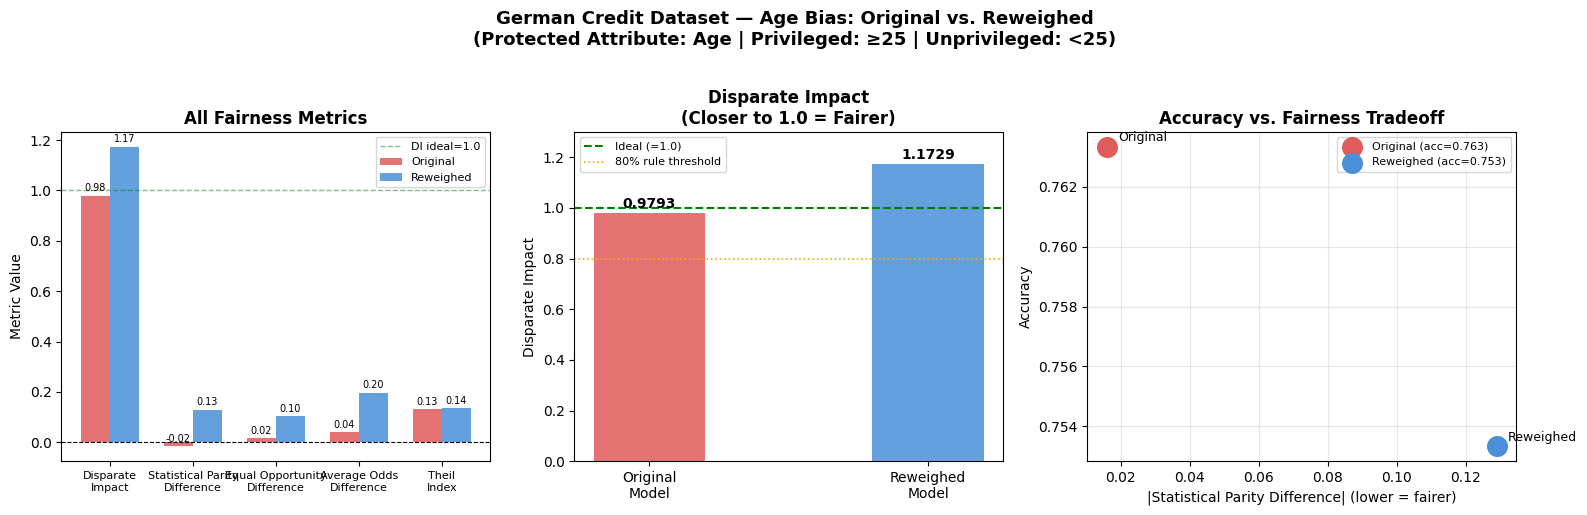

Chart saved as bias_analysis_results.png


In [7]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle(
    'German Credit Dataset — Age Bias: Original vs. Reweighed\n'
    '(Protected Attribute: Age | Privileged: ≥25 | Unprivileged: <25)',
    fontsize=13, fontweight='bold', y=1.02
)

metrics_labels = [
    'Disparate\nImpact',
    'Statistical Parity\nDifference',
    'Equal Opportunity\nDifference',
    'Average Odds\nDifference',
    'Theil\nIndex'
]

orig_vals = [
    clf_metric_orig.disparate_impact(),
    clf_metric_orig.statistical_parity_difference(),
    clf_metric_orig.equal_opportunity_difference(),
    clf_metric_orig.average_odds_difference(),
    clf_metric_orig.theil_index()
]

rw_vals = [
    clf_metric_rw.disparate_impact(),
    clf_metric_rw.statistical_parity_difference(),
    clf_metric_rw.equal_opportunity_difference(),
    clf_metric_rw.average_odds_difference(),
    clf_metric_rw.theil_index()
]

# --- Plot 1: All fairness metrics side by side ---
ax = axes[0]
x = np.arange(len(metrics_labels))
width = 0.35
bars1 = ax.bar(x - width/2, orig_vals, width, label='Original', color='#e05c5c', alpha=0.85)
bars2 = ax.bar(x + width/2, rw_vals,   width, label='Reweighed', color='#4a90d9', alpha=0.85)
ax.set_title('All Fairness Metrics', fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(metrics_labels, fontsize=8)
ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
ax.axhline(1, color='green', linewidth=1.0, linestyle='--', alpha=0.5, label='DI ideal=1.0')
ax.legend(fontsize=8)
ax.set_ylabel('Metric Value')
for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{bar.get_height():.2f}', ha='center', va='bottom', fontsize=7)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{bar.get_height():.2f}', ha='center', va='bottom', fontsize=7)

# --- Plot 2: Disparate Impact closeup ---
ax2 = axes[1]
di_vals = [clf_metric_orig.disparate_impact(), clf_metric_rw.disparate_impact()]
colors = ['#e05c5c', '#4a90d9']
bars = ax2.bar(['Original\nModel', 'Reweighed\nModel'], di_vals, color=colors, alpha=0.85, width=0.4)
ax2.axhline(1.0, color='green', linewidth=1.5, linestyle='--', label='Ideal (=1.0)')
ax2.axhline(0.8, color='orange', linewidth=1.2, linestyle=':', label='80% rule threshold')
ax2.set_title('Disparate Impact\n(Closer to 1.0 = Fairer)', fontweight='bold')
ax2.set_ylabel('Disparate Impact')
ax2.set_ylim(0, 1.3)
ax2.legend(fontsize=8)
for bar, val in zip(bars, di_vals):
    ax2.text(bar.get_x() + bar.get_width()/2, val + 0.02,
             f'{val:.4f}', ha='center', fontweight='bold')

# --- Plot 3: Accuracy vs Fairness tradeoff ---
ax3 = axes[2]
acc_orig = clf_metric_orig.accuracy()
acc_rw   = clf_metric_rw.accuracy()
ax3.scatter(abs(clf_metric_orig.statistical_parity_difference()), acc_orig,
            s=200, color='#e05c5c', zorder=5, label=f'Original (acc={acc_orig:.3f})')
ax3.scatter(abs(clf_metric_rw.statistical_parity_difference()), acc_rw,
            s=200, color='#4a90d9', zorder=5, label=f'Reweighed (acc={acc_rw:.3f})')
ax3.annotate('Original',
             (abs(clf_metric_orig.statistical_parity_difference()), acc_orig),
             textcoords='offset points', xytext=(8, 4), fontsize=9)
ax3.annotate('Reweighed',
             (abs(clf_metric_rw.statistical_parity_difference()), acc_rw),
             textcoords='offset points', xytext=(8, 4), fontsize=9)
ax3.set_xlabel('|Statistical Parity Difference| (lower = fairer)')
ax3.set_ylabel('Accuracy')
ax3.set_title('Accuracy vs. Fairness Tradeoff', fontweight='bold')
ax3.legend(fontsize=8)
ax3.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('bias_analysis_results.png', dpi=150, bbox_inches='tight')
plt.show()
print('Chart saved as bias_analysis_results.png')

## Cell 8 — Summary

In [8]:
print('=' * 65)
print('       SIMULATION SUMMARY — AIF360 REWEIGHING')
print('       German Credit Dataset | Protected Attribute: Age')
print('=' * 65)

def arrow(before, after, higher_is_better=True):
    improved = (after > before) if higher_is_better else (after < before)
    return '✅ IMPROVED' if improved else '⚠️  CHANGED'

print(f"\n{'Metric':<35} {'Before':>8} {'After':>8}  {'Result'}")
print('-' * 65)
print(f"{'Disparate Impact':<35} {clf_metric_orig.disparate_impact():>8.4f} {clf_metric_rw.disparate_impact():>8.4f}  {arrow(clf_metric_orig.disparate_impact(), clf_metric_rw.disparate_impact(), higher_is_better=True)}")
print(f"{'Stat. Parity Difference':<35} {clf_metric_orig.statistical_parity_difference():>8.4f} {clf_metric_rw.statistical_parity_difference():>8.4f}  {arrow(abs(clf_metric_orig.statistical_parity_difference()), abs(clf_metric_rw.statistical_parity_difference()), higher_is_better=False)}")
print(f"{'Equal Opportunity Diff.':<35} {clf_metric_orig.equal_opportunity_difference():>8.4f} {clf_metric_rw.equal_opportunity_difference():>8.4f}  {arrow(abs(clf_metric_orig.equal_opportunity_difference()), abs(clf_metric_rw.equal_opportunity_difference()), higher_is_better=False)}")
print(f"{'Average Odds Difference':<35} {clf_metric_orig.average_odds_difference():>8.4f} {clf_metric_rw.average_odds_difference():>8.4f}  {arrow(abs(clf_metric_orig.average_odds_difference()), abs(clf_metric_rw.average_odds_difference()), higher_is_better=False)}")
print(f"{'Theil Index':<35} {clf_metric_orig.theil_index():>8.4f} {clf_metric_rw.theil_index():>8.4f}  {arrow(clf_metric_orig.theil_index(), clf_metric_rw.theil_index(), higher_is_better=False)}")
print(f"{'Accuracy':<35} {clf_metric_orig.accuracy():>8.4f} {clf_metric_rw.accuracy():>8.4f}")
print('=' * 65)
print()
print('Notes:')
print('  Disparate Impact ideal  = 1.0  (ratio of favorable outcomes)')
print('  All difference metrics  = 0.0  (no gap between groups)')
print('  80% rule: DI < 0.8 is legally considered disparate impact')

       SIMULATION SUMMARY — AIF360 REWEIGHING
       German Credit Dataset | Protected Attribute: Age

Metric                                Before    After  Result
-----------------------------------------------------------------
Disparate Impact                      0.9793   1.1729  ✅ IMPROVED
Stat. Parity Difference              -0.0159   0.1290  ⚠️  CHANGED
Equal Opportunity Diff.               0.0151   0.1032  ⚠️  CHANGED
Average Odds Difference               0.0395   0.1974  ⚠️  CHANGED
Theil Index                           0.1310   0.1359  ⚠️  CHANGED
Accuracy                              0.7633   0.7533

Notes:
  Disparate Impact ideal  = 1.0  (ratio of favorable outcomes)
  All difference metrics  = 0.0  (no gap between groups)
  80% rule: DI < 0.8 is legally considered disparate impact
